In [72]:
import numpy as np
import open3d as o3d
from scipy.ndimage import binary_dilation, label, find_objects
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import heapq
from spatialmath.base import angle_wrap
from spatialmath import SO3
from scipy.interpolate import CubicSpline
from scipy.interpolate import make_interp_spline, make_lsq_spline
import pickle
from asrl.open3d_tests.env_builder import ArrayMap, DiffDrivePID, travel_along_path, collect_body_lidar_scans

In [ ]:
og = np.array([
    [0, 0, 0, 0, 0, 0, 0, 0],
    [0, 1, 1, 1, 0, 1, 1, 1],
    [0, 1, 1, 1, 0, 1, 1, 0],
    [0, 0, 1, 1, 1, 1, 1, 1],
    [0, 0, 1, 0, 0, 1, 0, 0],
    [0, 0, 1, 0, 0, 1, 0, 0],
    [0, 0, 1, 1, 1, 1, 0, 0],
])

m = ArrayMap(og, scale=1)

coord_waypoints = np.array([
    [2, 2],
    [6, 2],
    [6, 5],
    [3, 6],
    [2, 2]
    # [6, 2],
    # [6, 5],
    # [3, 6],
    # [2, 6],
    # [2, 5],
    # [3, 5],
    # [1, 1]
    #[2, 6],
    
    # [1, 1],
])

individual_paths = []

for i in range(1, len(coord_waypoints)):
    start = m.coord_to_xy(coord_waypoints[i-1], m.free_space.shape)
    goal = m.coord_to_xy(coord_waypoints[i], m.free_space.shape)
    
    res = 5
    path, free_space = m.plan_path_astar(start, goal, resolution=res)
    
    if i < len(coord_waypoints) - 1:
        individual_paths.append(path[:-1] / res)
    else:
        individual_paths.append(path / res)

path = np.vstack(individual_paths)

[[1 1 1 1 1 1 1 1 1]
 [1 0 0 0 1 0 0 0 1]
 [1 0 0 0 1 0 0 1 1]
 [1 1 0 0 0 0 0 0 1]
 [0 1 0 1 1 0 1 1 1]
 [0 1 0 1 1 0 1 0 0]
 [0 1 0 0 0 0 1 0 0]
 [0 1 1 1 1 1 1 0 0]]


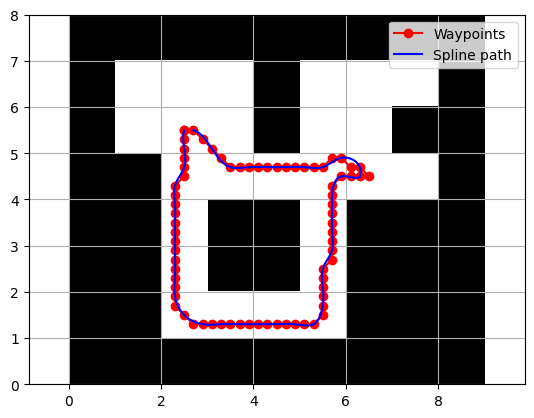

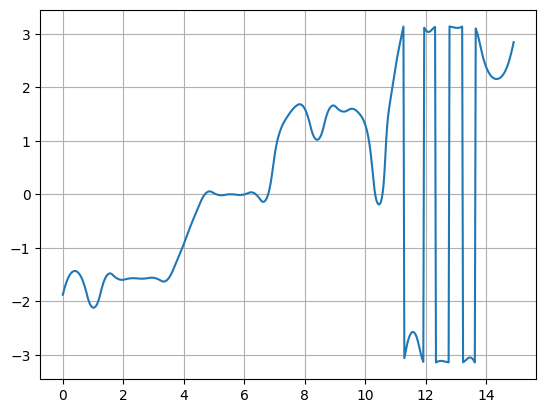

In [67]:
waypoints = path[:-1:2] #np.array(rdp(path.tolist(), epsilon=0.01))

deltas = np.diff(waypoints, axis=0)
dists = np.linalg.norm(deltas, axis=1)
s = np.concatenate([[0], np.cumsum(dists)])  # cumulative arc length

cs_x = make_interp_spline(s, waypoints[:, 0], k=3)
cs_y = make_interp_spline(s, waypoints[:, 1], k=3)

# Evaluate
s_fine = np.linspace(0, s[-1], 500)
x_fine = cs_x(s_fine)
y_fine = cs_y(s_fine)

dx_ds = cs_x.derivative()(s_fine)
dy_ds = cs_y.derivative()(s_fine)
angles = np.arctan2(dy_ds, dx_ds)

# Plot
plt.imshow(m.free_space, cmap='gray', origin='upper', extent=[0, m.free_space.shape[1], 0, m.free_space.shape[0]])
plt.plot(path[:, 0], path[:, 1], 'ro-', label='Waypoints')
plt.plot(x_fine, y_fine, 'b-', label='Spline path')
plt.axis('equal')
plt.legend()
plt.grid()
plt.show()

plt.plot(s_fine, angles)
plt.grid()
plt.show()

In [68]:
s_fine = np.linspace(0, s[-1], 500)
x_fine = cs_x(s_fine)
y_fine = cs_y(s_fine)

dx_ds = cs_x.derivative()(s_fine)
dy_ds = cs_y.derivative()(s_fine)
angles = np.arctan2(dy_ds, dx_ds)

traversed_path_poses = np.vstack([x_fine, y_fine, angles]).T
traversed_path_poses.shape

(500, 3)

In [73]:
# Build o3d scene
walls = m.to_o3d_geometry()
scene = o3d.t.geometry.RaycastingScene()

for cube in walls:
    scene.add_triangles(o3d.t.geometry.TriangleMesh.from_legacy(cube))
    
scans = collect_body_lidar_scans(traversed_path_poses, scene, r_max=3.0)

with open('lidar_scans.pkl', 'wb') as f:
    pickle.dump(scans, f)

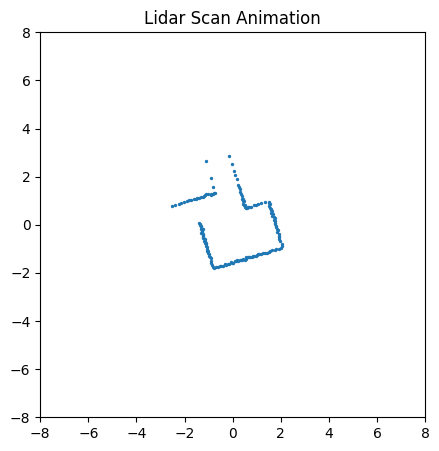

In [70]:
# Create plot
fig, ax = plt.subplots(figsize=(5, 5))
sc = ax.scatter([], [], s=2)
ax.set_xlim(-8, 8)
ax.set_ylim(-8, 8)
ax.set_aspect('equal')
ax.set_title('Lidar Scan Animation')

def update(frame):
    scan = scans[frame]
    sc.set_offsets(scan[:, :2])  # only x, y
    return sc,

ani = animation.FuncAnimation(
    fig, update, frames=len(scans), interval=100, blit=True
)

# Save as GIF
ani.save("lidar_scans.gif", writer="pillow", fps=10)